In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import itertools
import warnings
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_excel("B.23-INFLUENZA.xlsx" , header=4)
df.replace('NR', np.nan, inplace=True)
df_melted = df.melt(id_vars=['Week'], var_name='Year', value_name='Positive_Rate')

In [3]:
df_clean = df_melted[df_melted['Positive_Rate'] != '-'].copy()
df_clean['Positive_Rate'] = pd.to_numeric(df_clean['Positive_Rate'])
df_clean['Year'] = pd.to_numeric(df_clean['Year'])

In [4]:
def create_date_from_week(row):
    date_str = f"{int(row['Year'])}-{int(row['Week'])}-1"
    try:
        return pd.to_datetime(date_str, format='%Y-%W-%w')
    except:
        return np.nan
df_clean['Date'] = df_clean.apply(create_date_from_week, axis=1)
df_final = df_clean.dropna(subset=['Date']).sort_values('Date') 
df_final = df_final.groupby('Date')['Positive_Rate'].mean().to_frame()    
df = df_final


In [5]:
df = df.asfreq('W-MON')
df['Positive_Rate'] = df['Positive_Rate'].interpolate(method='cubic').bfill().ffill()
df[df < 0] = 0
df.columns = ['Positive_Rate']


In [6]:
# Statistical Summary
desc_stats = df['Positive_Rate'].describe()
print(desc_stats)


count    874.000000
mean       8.304050
std        9.728100
min        0.000000
25%        1.060000
50%        3.582262
75%       13.560000
max       43.050000
Name: Positive_Rate, dtype: float64


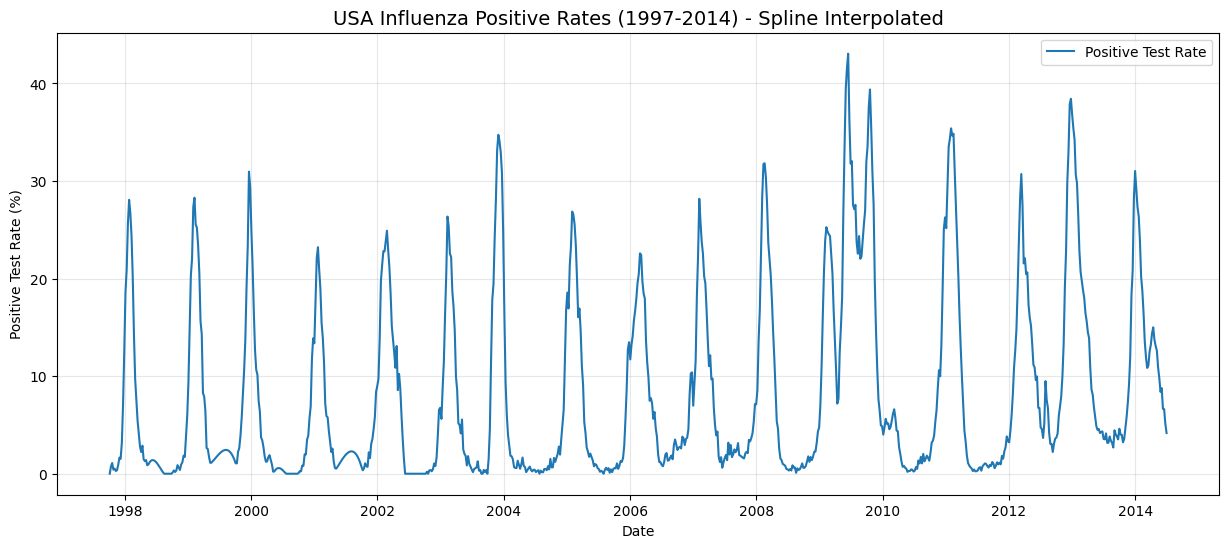

In [7]:
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Positive_Rate'], color='#1f77b4', linewidth=1.5, label='Positive Test Rate')
plt.title('USA Influenza Positive Rates (1997-2014) - Spline Interpolated', fontsize=14)
plt.ylabel('Positive Test Rate (%)')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

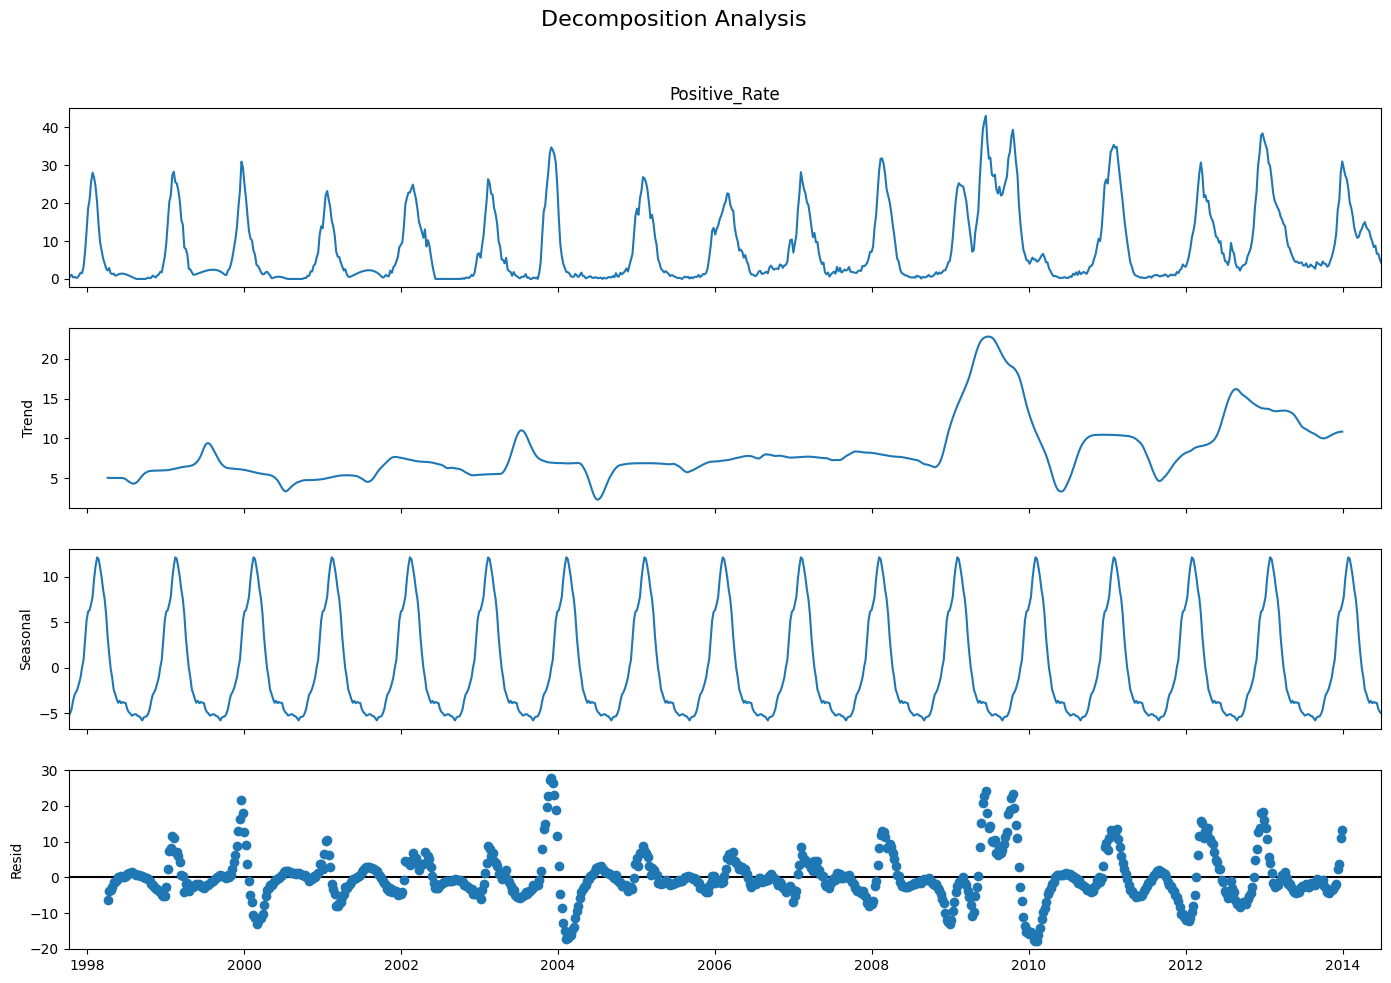

In [8]:
decomposition = sm.tsa.seasonal_decompose(df['Positive_Rate'], model='additive', period=52)
fig = decomposition.plot()
fig.set_size_inches(15, 10)
plt.suptitle('Decomposition Analysis', fontsize=16, y=1.02)
plt.show()

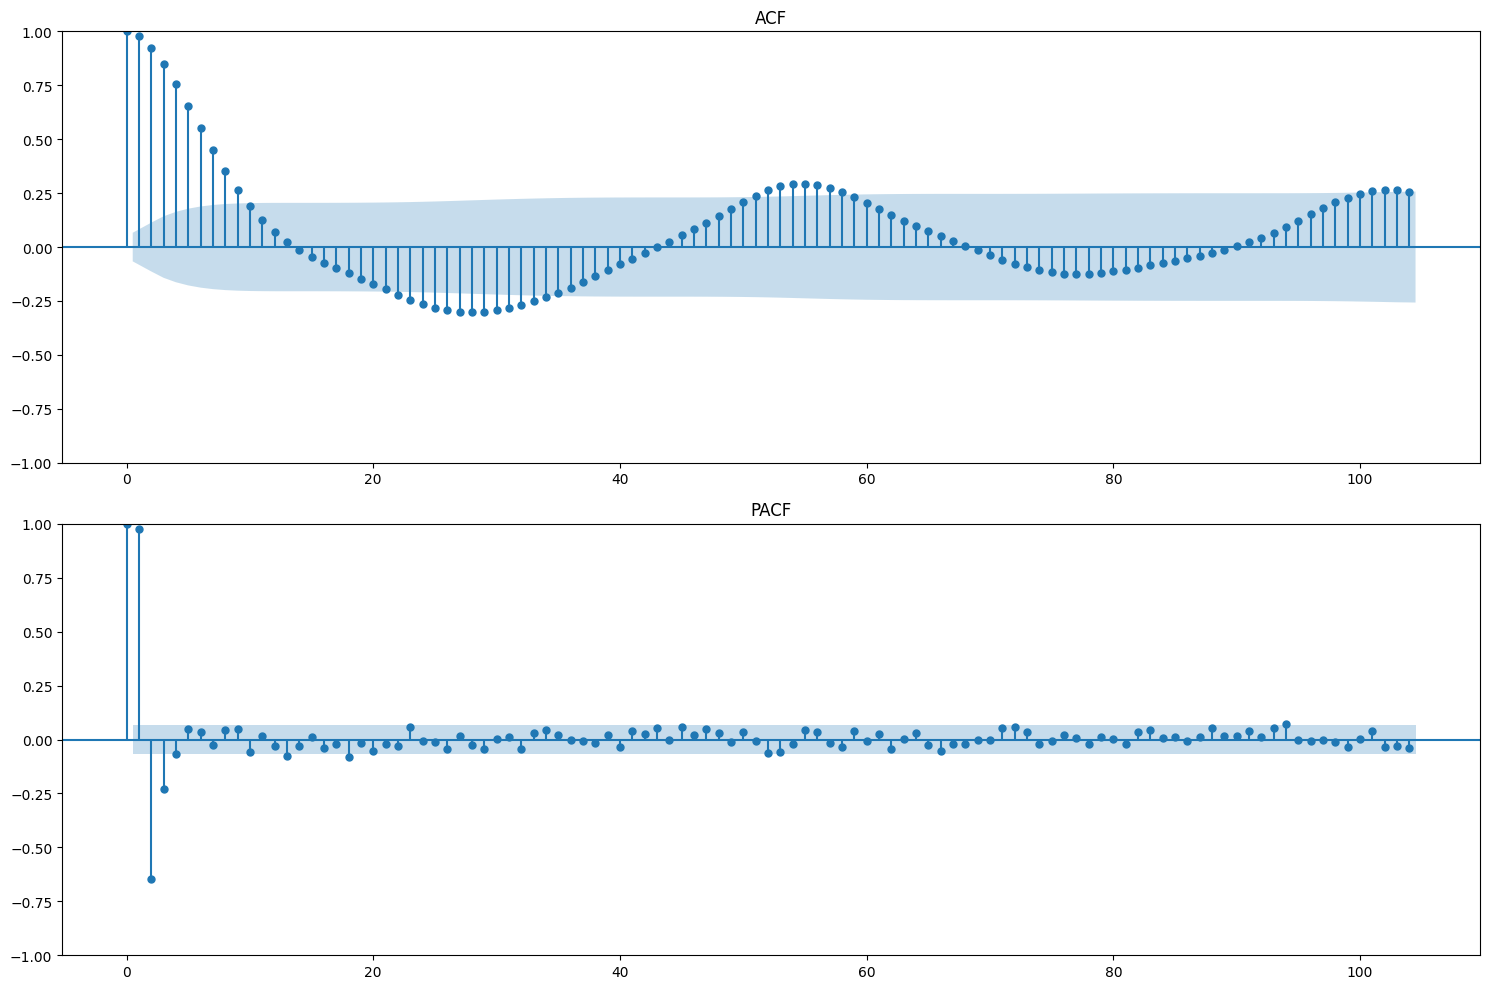

In [9]:
#ACF and PACF Graphics
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
plot_acf(df['Positive_Rate'], lags=104, ax=ax1, title='ACF')
plot_pacf(df['Positive_Rate'], lags=104, ax=ax2, title='PACF')
plt.tight_layout()
plt.show()

In [10]:
#ADF TESTING
adf_result = adfuller(df['Positive_Rate'])
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -6.7016243139412195
p-value: 3.876264495887855e-09


In [11]:
warnings.filterwarnings("ignore")
p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 52) for x in list(itertools.product(p, d, q))]
best_aic = float("inf")
best_param = None
best_seasonal_param = None
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(df['Positive_Rate'], 
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            
            results = mod.fit(disp=False)
            
           
            if results.aic < best_aic:
                best_aic = results.aic
                best_param = param
                best_seasonal_param = param_seasonal
                print(f"Best Value: SARIMAX{param}x{param_seasonal} - AIC:{best_aic:.2f}")
                
        except Exception as e:
            continue

print("-" * 50)
print(f"Order: {best_param}")
print(f"Seasonal Order: {best_seasonal_param}")
print(f"Best AIC: {best_aic}")

Best Value: SARIMAX(0, 0, 0)x(0, 0, 0, 52) - AIC:6929.90
Best Value: SARIMAX(0, 0, 0)x(0, 0, 1, 52) - AIC:6370.15
Best Value: SARIMAX(0, 0, 0)x(0, 1, 1, 52) - AIC:5543.29
Best Value: SARIMAX(0, 0, 1)x(0, 0, 1, 52) - AIC:5339.75
Best Value: SARIMAX(0, 0, 1)x(0, 1, 1, 52) - AIC:4617.36
Best Value: SARIMAX(0, 1, 0)x(0, 0, 0, 52) - AIC:3756.48
Best Value: SARIMAX(0, 1, 0)x(0, 0, 1, 52) - AIC:3523.89
Best Value: SARIMAX(0, 1, 0)x(0, 1, 1, 52) - AIC:3320.88
Best Value: SARIMAX(0, 1, 1)x(0, 0, 1, 52) - AIC:3270.56
Best Value: SARIMAX(0, 1, 1)x(0, 1, 1, 52) - AIC:3112.37
Best Value: SARIMAX(1, 0, 1)x(0, 1, 1, 52) - AIC:3101.47
Best Value: SARIMAX(1, 1, 0)x(0, 1, 1, 52) - AIC:2994.24
Best Value: SARIMAX(1, 1, 1)x(0, 1, 1, 52) - AIC:2976.95
--------------------------------------------------
Order: (1, 1, 1)
Seasonal Order: (0, 1, 1, 52)
Best AIC: 2976.9499271184686


 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            4     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.75629D+00    |proj g|=  1.56481D-01

At iterate    5    f=  1.69848D+00    |proj g|=  3.18510D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    4      8     11      1     0     0   3.117D-06   1.698D+00
  F =   1.6984839399991238     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
                                     SARIMAX Results                                      
Dep. Variable:                      Posit

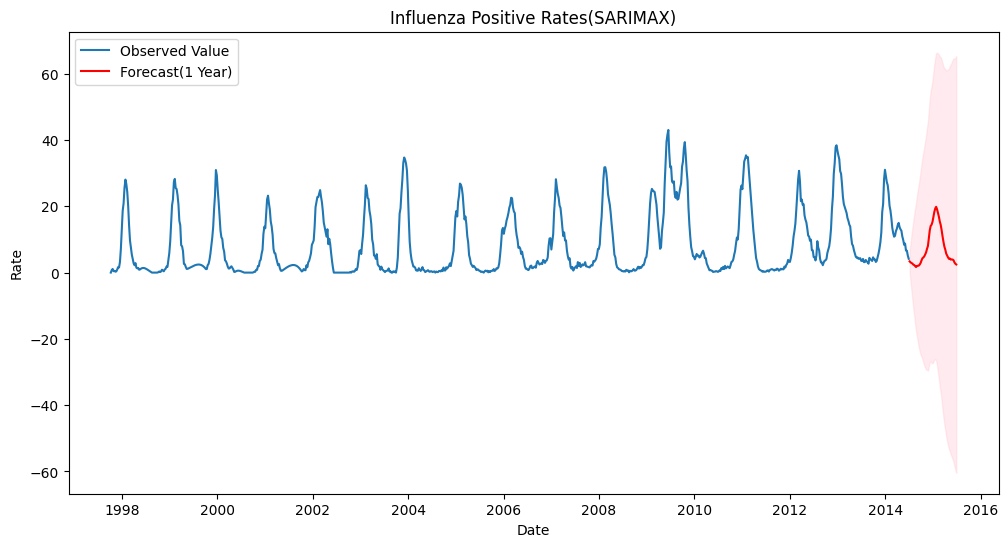

In [12]:
model = sm.tsa.statespace.SARIMAX(df['Positive_Rate'],
                                  order=(1, 1, 1),              # (p, d, q)
                                  seasonal_order=(0, 1, 1, 52), # (P, D, Q, s)
                                  enforce_stationarity=False,
                                  enforce_invertibility=False)

results = model.fit()


print(results.summary())


forecast = results.get_forecast(steps=52)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

plt.figure(figsize=(12, 6))

plt.plot(df.index, df['Positive_Rate'], label='Observed Value')

plt.plot(forecast_mean.index, forecast_mean, label='Forecast(1 Year)', color='red')

plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1], color='pink', alpha=0.3)

plt.title("Influenza Positive Rates(SARIMAX)")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.legend()
plt.show()

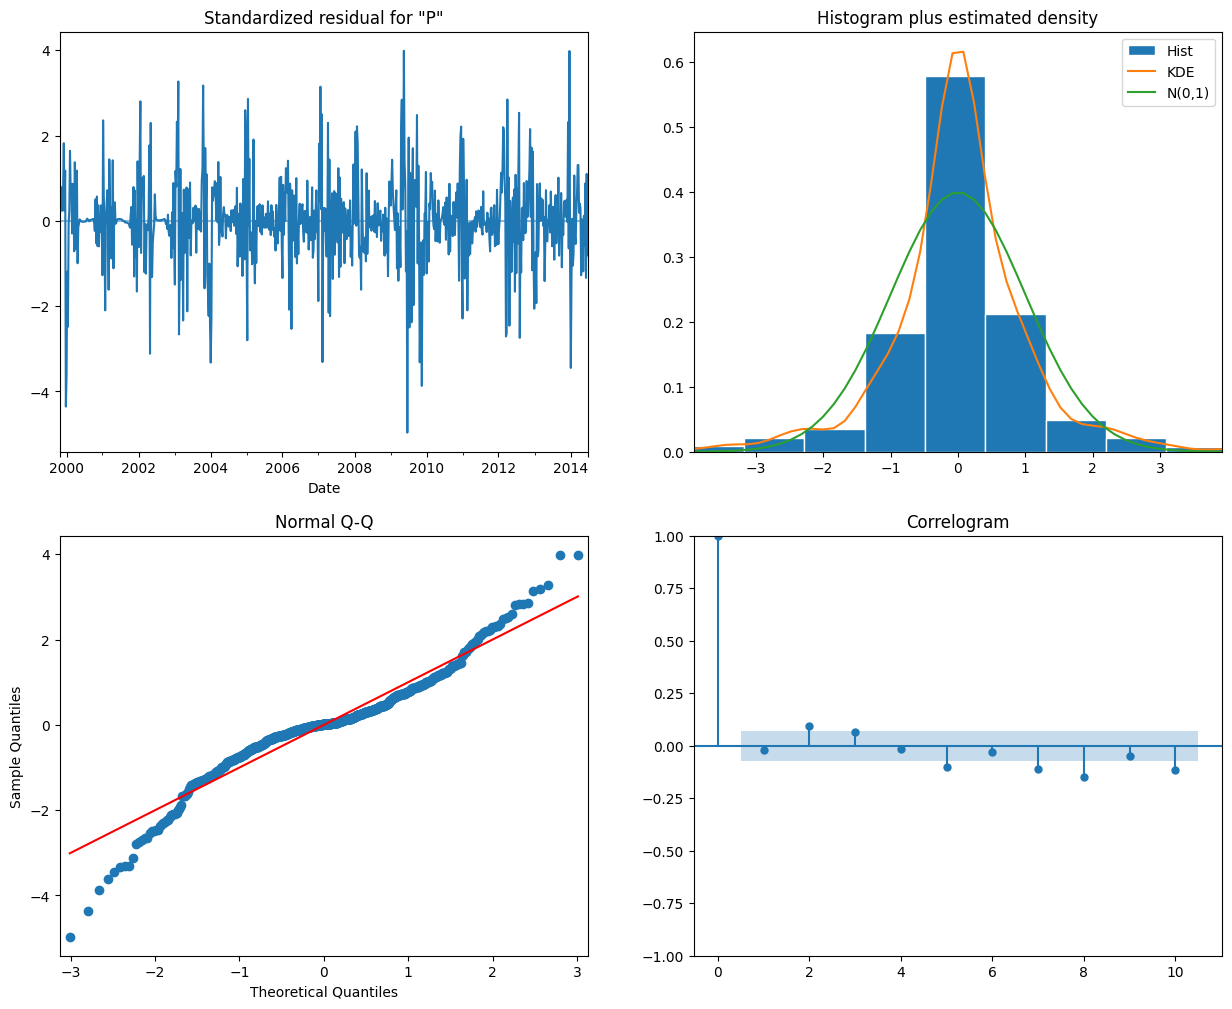

In [13]:

results.plot_diagnostics(figsize=(15, 12))
plt.show()

In [14]:
y_true = df['Positive_Rate'].iloc[52:]
y_pred = results.fittedvalues.iloc[52:]

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)

print(f"Mean Absolute Error(MAE): {mae:.4f}")
print(f"Root Mean Squared Error(RMSE): {rmse:.4f}")


Mean Absolute Error(MAE): 1.1053
Root Mean Squared Error(RMSE): 1.6774
